In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
try:
    from google.colab import files
    import os
    if not os.path.exists('cardio_train.csv'):
        uploaded = files.upload()
except ImportError:
    pass

In [ ]:
df = pd.read_csv('cardio_train.csv', sep=';')
print("Shape:", df.shape)
df.head()

Shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [ ]:
print("Column names:", df.columns.tolist())
print()
print(df.dtypes)
print()
df.describe().T

Column names: ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object



,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


In [ ]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate patient ids:", df['id'].duplicated().sum())

Missing values per column:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Duplicate rows: 0
Duplicate patient ids: 0


In [ ]:
implausible = pd.DataFrame({
    'issue': [
        'ap_hi <= 0 or > 250',
        'ap_lo <= 0 or > 200',
        'ap_hi < ap_lo (systolic below diastolic)',
        'height < 100 or > 220 cm',
        'weight < 30 or > 200 kg'
    ],
    'count': [
        ((df['ap_hi'] <= 0) | (df['ap_hi'] > 250)).sum(),
        ((df['ap_lo'] <= 0) | (df['ap_lo'] > 200)).sum(),
        (df['ap_hi'] < df['ap_lo']).sum(),
        ((df['height'] < 100) | (df['height'] > 220)).sum(),
        ((df['weight'] < 30) | (df['weight'] > 200)).sum(),
    ]
})
implausible['pct_of_rows'] = (implausible['count'] / len(df) * 100).round(2)
implausible

,issue,count,pct_of_rows
0,ap_hi <= 0 or > 250,47,0.07
1,ap_lo <= 0 or > 200,975,1.39
2,ap_hi < ap_lo (systolic below diastolic),1234,1.76
3,height < 100 or > 220 cm,30,0.04
4,weight < 30 or > 200 kg,7,0.01


In [ ]:
print("Target distribution (cardio):")
print(df['cardio'].value_counts())
print((df['cardio'].value_counts(normalize=True) * 100).round(2))

Target distribution (cardio):
cardio
0    35021
1    34979
Name: count, dtype: int64
cardio
0    50.03
1    49.97
Name: proportion, dtype: float64


In [ ]:
categorical_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
for c in categorical_cols:
    print(c, "->", sorted(df[c].unique()))

gender -> [np.int64(1), np.int64(2)]
cholesterol -> [np.int64(1), np.int64(2), np.int64(3)]
gluc -> [np.int64(1), np.int64(2), np.int64(3)]
smoke -> [np.int64(0), np.int64(1)]
alco -> [np.int64(0), np.int64(1)]
active -> [np.int64(0), np.int64(1)]


**Exploratory Data Analysis**

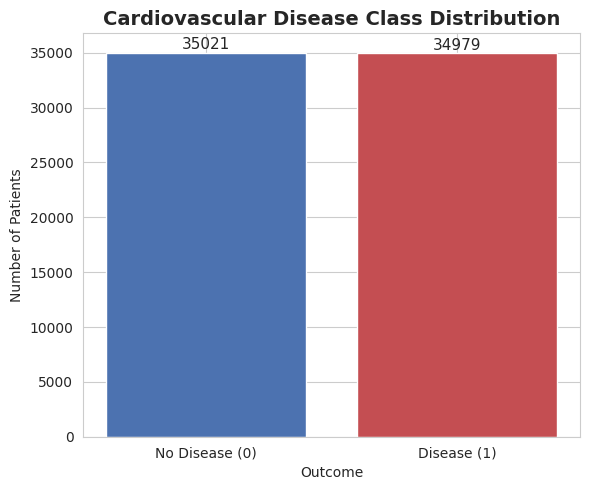

In [ ]:
df['age_years'] = (df['age'] / 365.25)

fig, ax = plt.subplots(figsize=(6, 5))
counts = df['cardio'].value_counts().sort_index()
bars = ax.bar(['No Disease (0)', 'Disease (1)'], counts.values, color=['#4C72B0', '#C44E52'])
ax.set_title('Cardiovascular Disease Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Outcome')
ax.set_ylabel('Number of Patients')
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 300, f'{int(b.get_height())}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

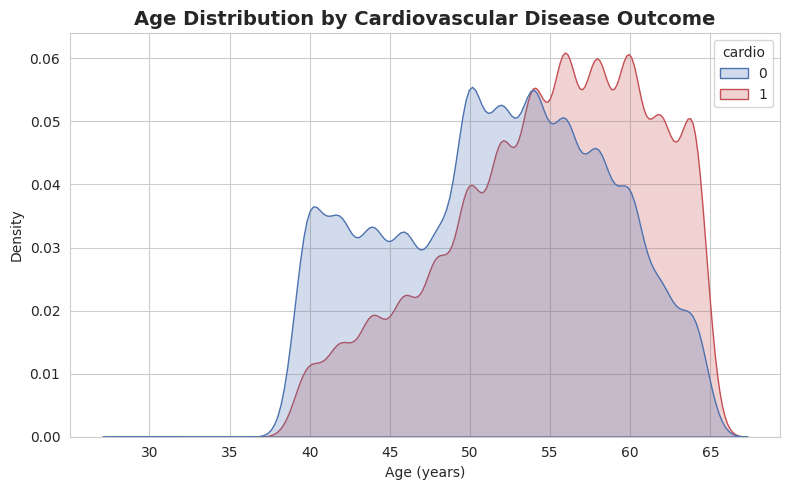

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(data=df, x='age_years', hue='cardio', fill=True, common_norm=False, palette=['#4C72B0', '#C44E52'], ax=ax)
ax.set_title('Age Distribution by Cardiovascular Disease Outcome', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

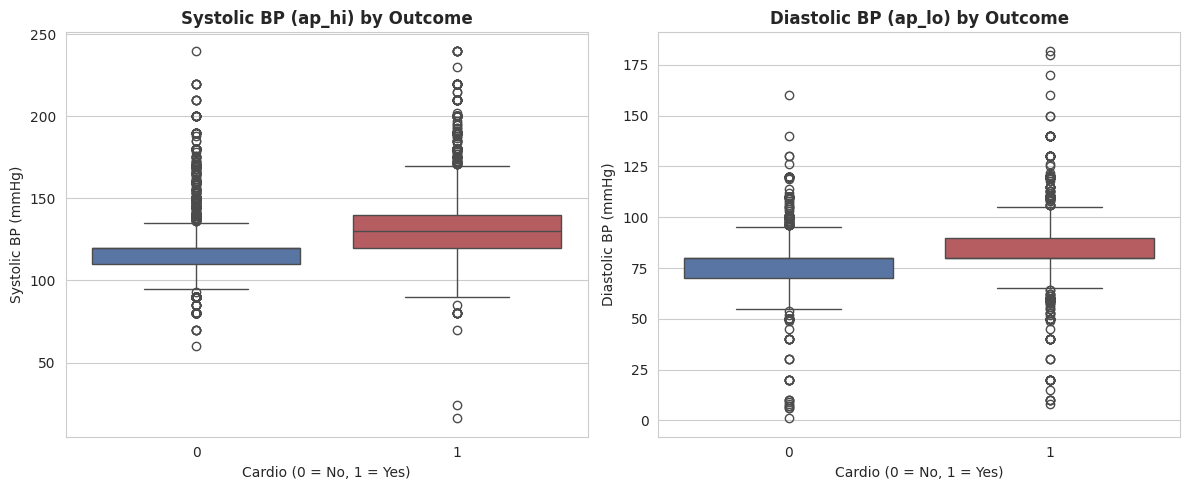

In [ ]:
clean_bp = df[(df['ap_hi'] > 0) & (df['ap_hi'] <= 250) & (df['ap_lo'] > 0) & (df['ap_lo'] <= 200) & (df['ap_hi'] >= df['ap_lo'])]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=clean_bp, x='cardio', y='ap_hi', hue='cardio', palette=['#4C72B0', '#C44E52'], legend=False, ax=axes[0])
axes[0].set_title('Systolic BP (ap_hi) by Outcome', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cardio (0 = No, 1 = Yes)')
axes[0].set_ylabel('Systolic BP (mmHg)')

sns.boxplot(data=clean_bp, x='cardio', y='ap_lo', hue='cardio', palette=['#4C72B0', '#C44E52'], legend=False, ax=axes[1])
axes[1].set_title('Diastolic BP (ap_lo) by Outcome', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cardio (0 = No, 1 = Yes)')
axes[1].set_ylabel('Diastolic BP (mmHg)')
plt.tight_layout()
plt.show()

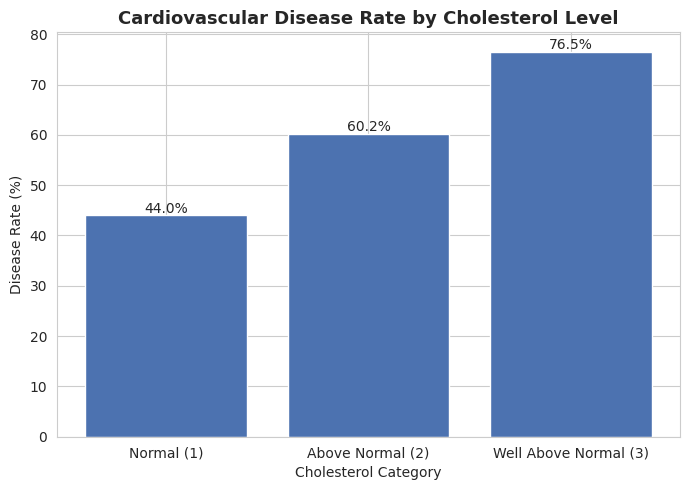

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
rate = df.groupby('cholesterol')['cardio'].mean() * 100
bars = ax.bar(['Normal (1)', 'Above Normal (2)', 'Well Above Normal (3)'], rate.reindex([1,2,3]).values, color='#4C72B0')
ax.set_title('Cardiovascular Disease Rate by Cholesterol Level', fontsize=13, fontweight='bold')
ax.set_xlabel('Cholesterol Category')
ax.set_ylabel('Disease Rate (%)')
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5, f'{b.get_height():.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

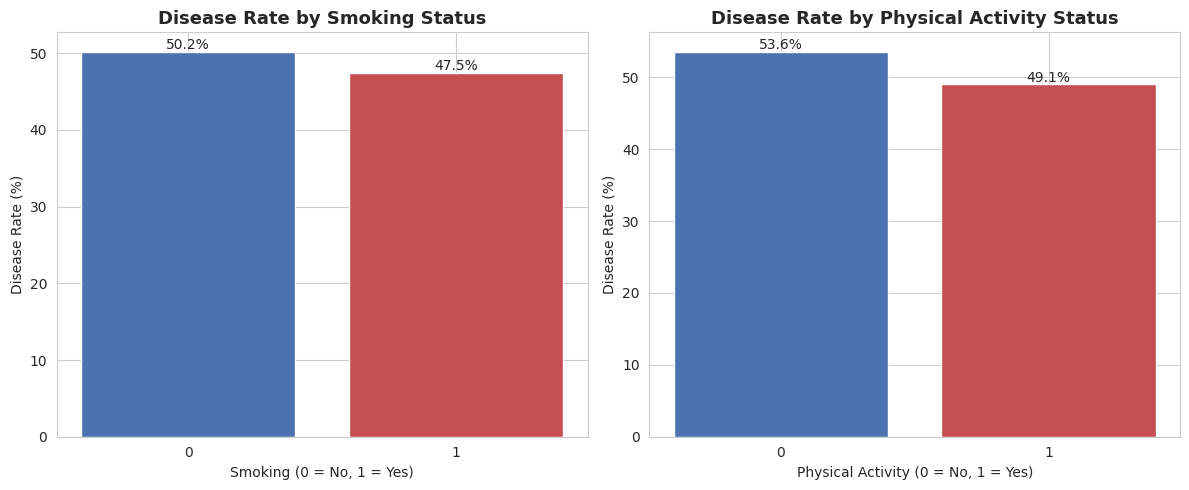

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, title in zip(axes, ['smoke', 'active'], ['Smoking', 'Physical Activity']):
    rate = df.groupby(col)['cardio'].mean() * 100
    bars = ax.bar(rate.index.astype(str), rate.values, color=['#4C72B0', '#C44E52'])
    ax.set_title(f'Disease Rate by {title} Status', fontsize=13, fontweight='bold')
    ax.set_xlabel(f'{title} (0 = No, 1 = Yes)')
    ax.set_ylabel('Disease Rate (%)')
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3, f'{b.get_height():.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

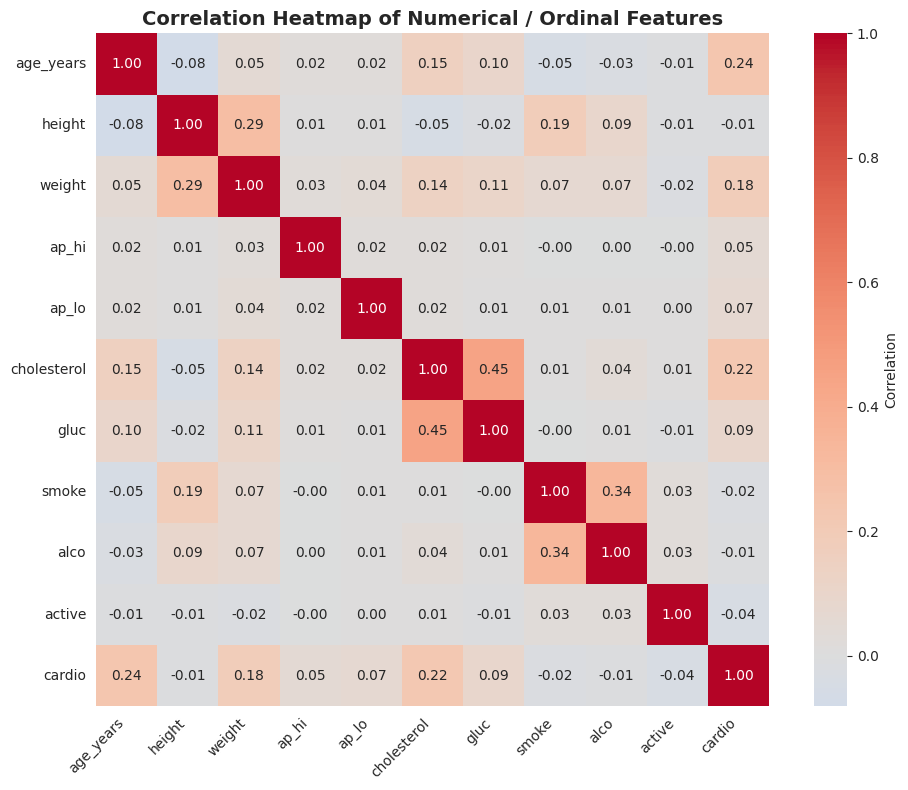

In [ ]:
corr_cols = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']
plt.figure(figsize=(10, 8))
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap of Numerical / Ordinal Features', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
corr_with_target = corr['cardio'].drop('cardio').sort_values(key=abs, ascending=False)
print("Features ranked by absolute correlation with cardio:")
print(corr_with_target)

Features ranked by absolute correlation with cardio:
age_years      0.238159
cholesterol    0.221147
weight         0.181660
gluc           0.089307
ap_lo          0.065719
ap_hi          0.054475
active        -0.035653
smoke         -0.015486
height        -0.010821
alco          -0.007330
Name: cardio, dtype: float64


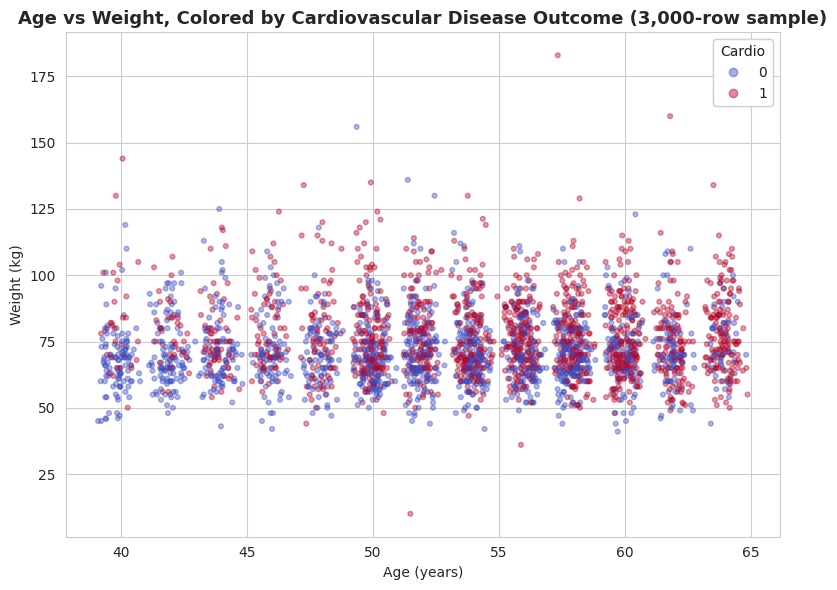

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
sample = df.sample(3000, random_state=RANDOM_STATE)
scatter = ax.scatter(sample['age_years'], sample['weight'], c=sample['cardio'], cmap='coolwarm', alpha=0.4, s=12)
ax.set_title('Age vs Weight, Colored by Cardiovascular Disease Outcome (3,000-row sample)', fontsize=13, fontweight='bold')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Weight (kg)')
legend1 = ax.legend(*scatter.legend_elements(), title='Cardio')
ax.add_artist(legend1)
plt.tight_layout()
plt.show()

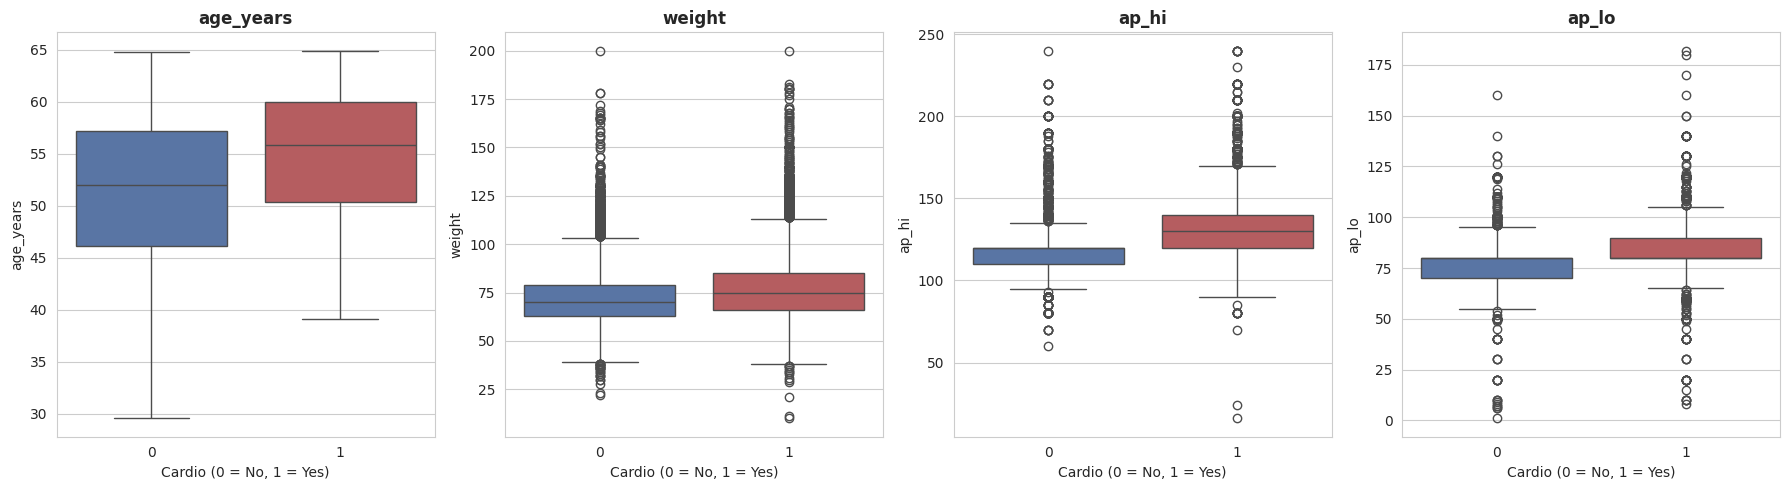

In [ ]:
important_numeric = ['age_years', 'weight', 'ap_hi', 'ap_lo']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, important_numeric):
    plot_df = clean_bp if col in ['ap_hi', 'ap_lo'] else df
    sns.boxplot(data=plot_df, x='cardio', y=col, hue='cardio', palette=['#4C72B0', '#C44E52'], legend=False, ax=ax)
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Cardio (0 = No, 1 = Yes)')
plt.tight_layout()
plt.show()

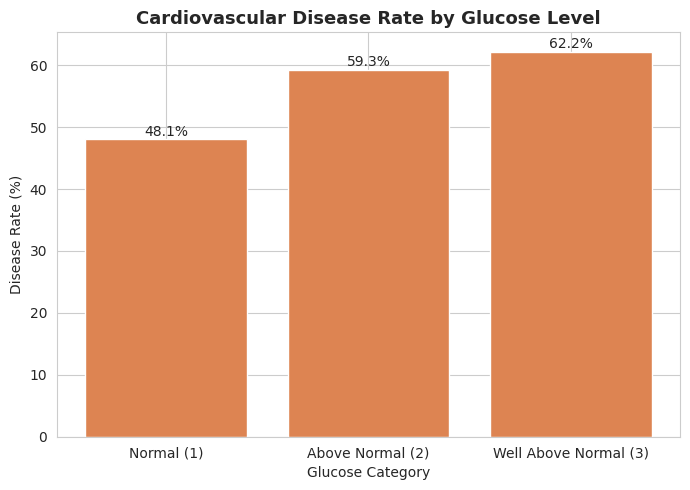

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
rate = df.groupby('gluc')['cardio'].mean() * 100
bars = ax.bar(['Normal (1)', 'Above Normal (2)', 'Well Above Normal (3)'], rate.reindex([1,2,3]).values, color='#DD8452')
ax.set_title('Cardiovascular Disease Rate by Glucose Level', fontsize=13, fontweight='bold')
ax.set_xlabel('Glucose Category')
ax.set_ylabel('Disease Rate (%)')
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5, f'{b.get_height():.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

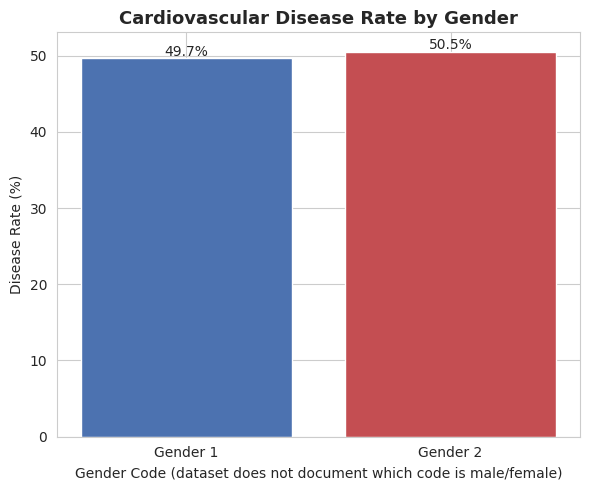

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
rate = df.groupby('gender')['cardio'].mean() * 100
bars = ax.bar(['Gender 1', 'Gender 2'], rate.reindex([1,2]).values, color=['#4C72B0', '#C44E52'])
ax.set_title('Cardiovascular Disease Rate by Gender', fontsize=13, fontweight='bold')
ax.set_xlabel('Gender Code (dataset does not document which code is male/female)')
ax.set_ylabel('Disease Rate (%)')
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3, f'{b.get_height():.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

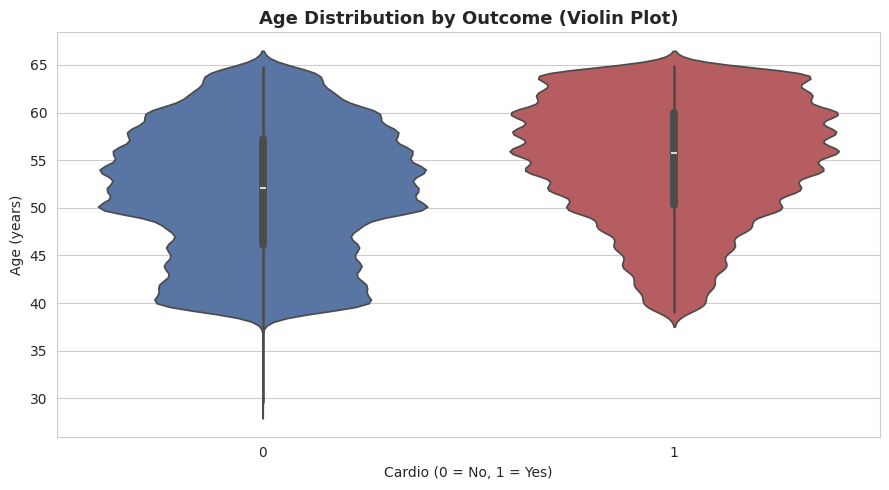

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(data=df, x='cardio', y='age_years', hue='cardio', palette=['#4C72B0', '#C44E52'], legend=False, ax=ax)
ax.set_title('Age Distribution by Outcome (Violin Plot)', fontsize=13, fontweight='bold')
ax.set_xlabel('Cardio (0 = No, 1 = Yes)')
ax.set_ylabel('Age (years)')
plt.tight_layout()
plt.show()

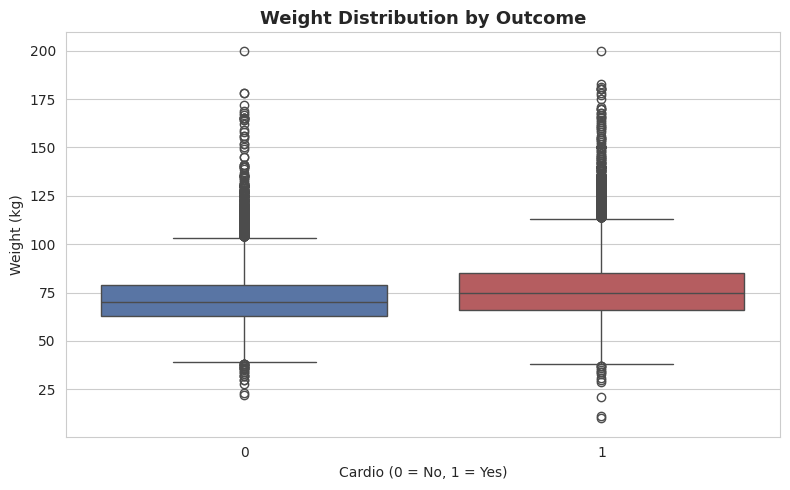

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='cardio', y='weight', hue='cardio', palette=['#4C72B0', '#C44E52'], legend=False, ax=ax)
ax.set_title('Weight Distribution by Outcome', fontsize=13, fontweight='bold')
ax.set_xlabel('Cardio (0 = No, 1 = Yes)')
ax.set_ylabel('Weight (kg)')
plt.tight_layout()
plt.show()

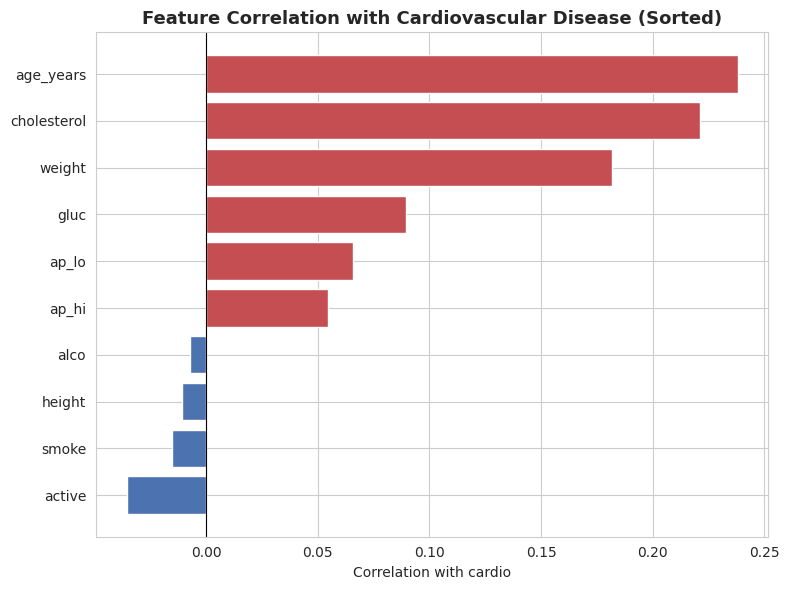

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
sorted_corr = corr_with_target.sort_values()
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in sorted_corr]
ax.barh(sorted_corr.index, sorted_corr.values, color=colors)
ax.set_title('Feature Correlation with Cardiovascular Disease (Sorted)', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlation with cardio')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [ ]:
interpretation_lines = []
age_diff = df.groupby('cardio')['age_years'].mean()
interpretation_lines.append(f"Mean age is {age_diff[1]:.1f} years for patients with disease vs {age_diff[0]:.1f} years for those without.")

bp_diff = clean_bp.groupby('cardio')['ap_hi'].mean()
interpretation_lines.append(f"Mean systolic BP is {bp_diff[1]:.1f} mmHg for patients with disease vs {bp_diff[0]:.1f} mmHg for those without.")

chol_rate = df.groupby('cholesterol')['cardio'].mean() * 100
interpretation_lines.append(f"Disease rate rises from {chol_rate[1]:.1f}% (normal cholesterol) to {chol_rate[3]:.1f}% (well above normal cholesterol).")

top_corr_feature = corr_with_target.index[0]
interpretation_lines.append(f"The feature with the strongest linear correlation to cardiovascular disease in this dataset is '{top_corr_feature}' (correlation = {corr_with_target.iloc[0]:.3f}).")

for line in interpretation_lines:
    print("-", line)

- Mean age is 54.9 years for patients with disease vs 51.7 years for those without.
- Mean systolic BP is 133.9 mmHg for patients with disease vs 119.6 mmHg for those without.
- Disease rate rises from 44.0% (normal cholesterol) to 76.5% (well above normal cholesterol).
- The feature with the strongest linear correlation to cardiovascular disease in this dataset is 'age_years' (correlation = 0.238).


**Feature Engineering & Scaling, Handling Missing Data**

In [ ]:
df_clean = df.copy()

bp_mask = (df_clean['ap_hi'] <= 0) | (df_clean['ap_hi'] > 250) | (df_clean['ap_lo'] <= 0) | (df_clean['ap_lo'] > 200) | (df_clean['ap_hi'] < df_clean['ap_lo'])
height_mask = (df_clean['height'] < 100) | (df_clean['height'] > 220)
weight_mask = (df_clean['weight'] < 30) | (df_clean['weight'] > 200)

print("Rows flagged for implausible blood pressure:", bp_mask.sum())
print("Rows flagged for implausible height:", height_mask.sum())
print("Rows flagged for implausible weight:", weight_mask.sum())

df_clean.loc[bp_mask, ['ap_hi', 'ap_lo']] = np.nan
df_clean.loc[height_mask, 'height'] = np.nan
df_clean.loc[weight_mask, 'weight'] = np.nan

print()
print("Missing values AFTER flagging implausible readings:")
print(df_clean[['ap_hi', 'ap_lo', 'height', 'weight']].isna().sum())

Rows flagged for implausible blood pressure: 1289
Rows flagged for implausible height: 30
Rows flagged for implausible weight: 7

Missing values AFTER flagging implausible readings:
ap_hi     1289
ap_lo     1289
height      30
weight       7
dtype: int64


In [ ]:
df_clean['age_years'] = df_clean['age'] / 365.25
df_clean = df_clean.drop(columns=['id', 'age'])
print(df_clean.columns.tolist())

['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years']


In [ ]:
df_clean['bmi'] = df_clean['weight'] / ((df_clean['height'] / 100) ** 2)
df_clean['pulse_pressure'] = df_clean['ap_hi'] - df_clean['ap_lo']

def age_bucket(age):
    if age < 40:
        return 'under_40'
    elif age < 50:
        return '40s'
    elif age < 60:
        return '50s'
    else:
        return '60_plus'

df_clean['age_group'] = df_clean['age_years'].apply(age_bucket)

print(df_clean[['height', 'weight', 'bmi', 'ap_hi', 'ap_lo', 'pulse_pressure', 'age_years', 'age_group']].head(8))

   height  weight        bmi  ap_hi  ap_lo  pulse_pressure  age_years  \
0   168.0    62.0  21.967120  110.0   80.0            30.0  50.357290   
1   156.0    85.0  34.927679  140.0   90.0            50.0  55.381246   
2   165.0    64.0  23.507805  130.0   70.0            60.0  51.627652   
3   169.0    82.0  28.710479  150.0  100.0            50.0  48.249144   
4   156.0    56.0  23.011177  100.0   60.0            40.0  47.841205   
5   151.0    67.0  29.384676  120.0   80.0            40.0  59.997262   
6   157.0    93.0  37.729725  130.0   80.0            50.0  60.542094   
7   178.0    95.0  29.983588  130.0   90.0            40.0  61.831622   

  age_group  
0       50s  
1       50s  
2       50s  
3       40s  
4       40s  
5       50s  
6   60_plus  
7   60_plus  


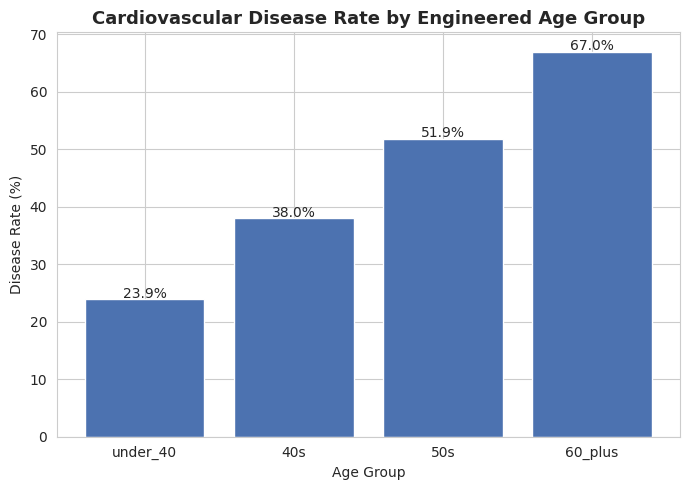

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
rate = df_clean.groupby('age_group')['cardio'].mean().reindex(['under_40', '40s', '50s', '60_plus']) * 100
bars = ax.bar(rate.index, rate.values, color='#4C72B0')
ax.set_title('Cardiovascular Disease Rate by Engineered Age Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Disease Rate (%)')
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3, f'{b.get_height():.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

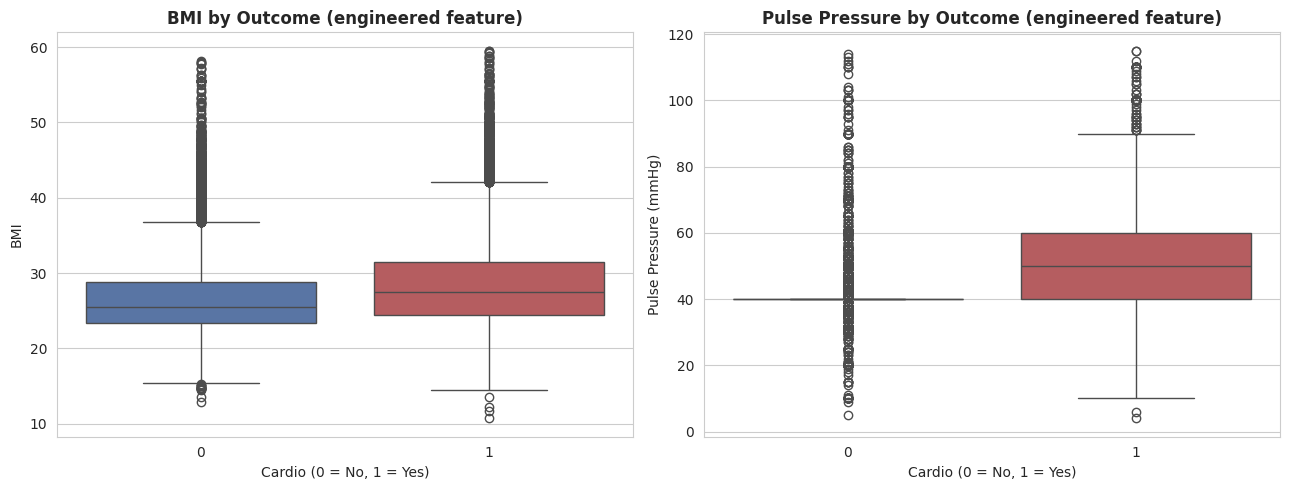

In [ ]:
bmi_plot_df = df_clean[(df_clean['bmi'] > 10) & (df_clean['bmi'] < 60)]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=bmi_plot_df, x='cardio', y='bmi', hue='cardio', palette=['#4C72B0', '#C44E52'], legend=False, ax=axes[0])
axes[0].set_title('BMI by Outcome (engineered feature)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cardio (0 = No, 1 = Yes)')
axes[0].set_ylabel('BMI')

pp_plot_df = df_clean[(df_clean['pulse_pressure'] > 0) & (df_clean['pulse_pressure'] < 120)]
sns.boxplot(data=pp_plot_df, x='cardio', y='pulse_pressure', hue='cardio', palette=['#4C72B0', '#C44E52'], legend=False, ax=axes[1])
axes[1].set_title('Pulse Pressure by Outcome (engineered feature)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cardio (0 = No, 1 = Yes)')
axes[1].set_ylabel('Pulse Pressure (mmHg)')
plt.tight_layout()
plt.show()

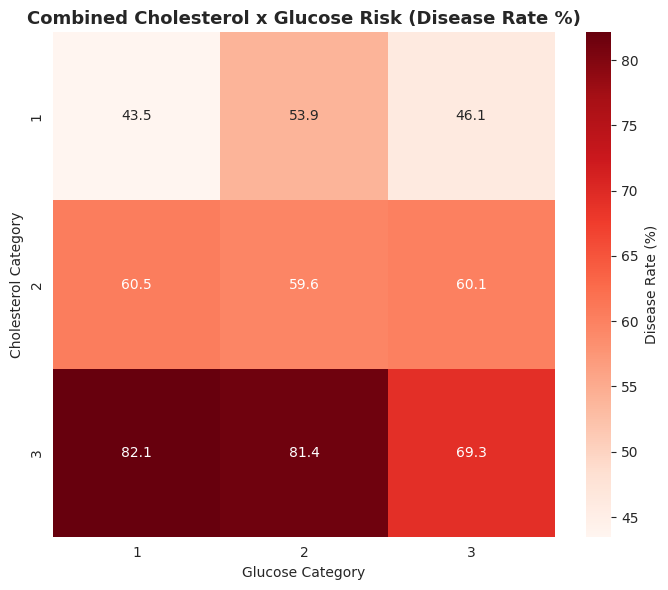

In [ ]:
risk_pivot = df_clean.pivot_table(values='cardio', index='cholesterol', columns='gluc', aggfunc='mean') * 100
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(risk_pivot, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': 'Disease Rate (%)'}, ax=ax)
ax.set_title('Combined Cholesterol x Glucose Risk (Disease Rate %)', fontsize=13, fontweight='bold')
ax.set_xlabel('Glucose Category')
ax.set_ylabel('Cholesterol Category')
plt.tight_layout()
plt.show()

In [ ]:
demo = df_clean[['height', 'weight', 'bmi', 'age_group']].head(5)
print("Raw features (height, weight):")
print(demo[['height', 'weight']].values)
print()
print("Engineered feature (bmi):")
print(demo['bmi'].round(2).values)
print()
print("Engineered categorical feature (age_group):")
print(demo['age_group'].values)
print()
scaler_demo = StandardScaler()
scaled_demo = scaler_demo.fit_transform(df_clean[['bmi']].dropna().head(5))
print("Scaled version of bmi (StandardScaler, illustrative fit on this 5-row slice):")
print(scaled_demo.ravel())

Raw features (height, weight):
[[168.  62.]
 [156.  85.]
 [165.  64.]
 [169.  82.]
 [156.  56.]]

Engineered feature (bmi):
[21.97 34.93 23.51 28.71 23.01]

Engineered categorical feature (age_group):
<StringArray>
['50s', '50s', '50s', '40s', '40s']
Length: 5, dtype: str

Scaled version of bmi (StandardScaler, illustrative fit on this 5-row slice):
[-0.91934134  1.7535824  -0.6015978   0.47137682 -0.70402008]


**Train-Test Split**

In [ ]:
feature_cols = [c for c in df_clean.columns if c != 'cardio']
X = df_clean[feature_cols]
y = df_clean['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print()
print("Training class distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))
print()
print("Testing class distribution (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training samples: 56000
Testing samples: 14000

Training class distribution (%):
cardio
0    50.03
1    49.97
Name: proportion, dtype: float64

Testing class distribution (%):
cardio
0    50.03
1    49.97
Name: proportion, dtype: float64


In [ ]:
numeric_features = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi', 'pulse_pressure']
ordinal_features = ['cholesterol', 'gluc']
categorical_features = ['gender', 'age_group']
binary_features = ['smoke', 'alco', 'active']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('ord', ordinal_transformer, ordinal_features),
    ('cat', categorical_transformer, categorical_features),
    ('bin', 'passthrough', binary_features)
])

print("Numeric (imputed + scaled):", numeric_features)
print("Ordinal (imputed + scaled):", ordinal_features)
print("Categorical (imputed + one-hot):", categorical_features)
print("Binary passthrough:", binary_features)

Numeric (imputed + scaled): ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi', 'pulse_pressure']
Ordinal (imputed + scaled): ['cholesterol', 'gluc']
Categorical (imputed + one-hot): ['gender', 'age_group']
Binary passthrough: ['smoke', 'alco', 'active']


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=15),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE)
}

pipelines = {}
for name, clf in models.items():
    pipelines[name] = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', clf)])
    pipelines[name].fit(X_train, y_train)

print("Models trained:", list(pipelines.keys()))

Models trained: ['Logistic Regression', 'K-Nearest Neighbors', 'Decision Tree', 'Random Forest']


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'accuracy': 'accuracy', 'f1': 'f1', 'roc_auc': 'roc_auc'}

cv_results = {}
for name, pipe in pipelines.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    cv_results[name] = scores

cv_summary = pd.DataFrame({
    name: {
        'CV Accuracy Mean': res['test_accuracy'].mean(),
        'CV Accuracy Std': res['test_accuracy'].std(),
        'CV F1 Mean': res['test_f1'].mean(),
        'CV F1 Std': res['test_f1'].std(),
        'CV ROC-AUC Mean': res['test_roc_auc'].mean(),
        'CV ROC-AUC Std': res['test_roc_auc'].std(),
    }
    for name, res in cv_results.items()
}).T

cv_summary.round(4)

,CV Accuracy Mean,CV Accuracy Std,CV F1 Mean,CV F1 Std,CV ROC-AUC Mean,CV ROC-AUC Std
Logistic Regression,0.7252,0.0033,0.7103,0.0051,0.7894,0.0027
K-Nearest Neighbors,0.7138,0.0036,0.7076,0.0043,0.7740,0.0035
Decision Tree,0.7251,0.0036,0.7050,0.0047,0.7893,0.0029
Random Forest,0.7298,0.0026,0.7167,0.0037,0.7971,0.0024


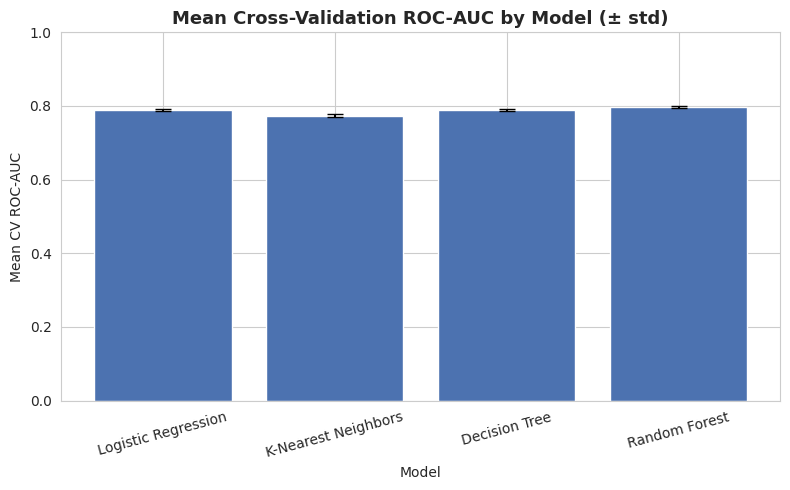

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
means = cv_summary['CV ROC-AUC Mean']
stds = cv_summary['CV ROC-AUC Std']
bars = ax.bar(means.index, means.values, yerr=stds.values, capsize=6, color='#4C72B0')
ax.set_title('Mean Cross-Validation ROC-AUC by Model (± std)', fontsize=13, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Mean CV ROC-AUC')
ax.set_ylim(0, 1.0)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
results = []
predictions = {}
probabilities = {}

for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    predictions[name] = y_pred
    probabilities[name] = y_proba

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df.round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Logistic Regression,0.7195,0.7419,0.6727,0.7056,0.7856
K-Nearest Neighbors,0.7149,0.7222,0.6981,0.7099,0.7713
Decision Tree,0.7226,0.7580,0.6535,0.7019,0.7846
Random Forest,0.7271,0.7481,0.6844,0.7148,0.7922


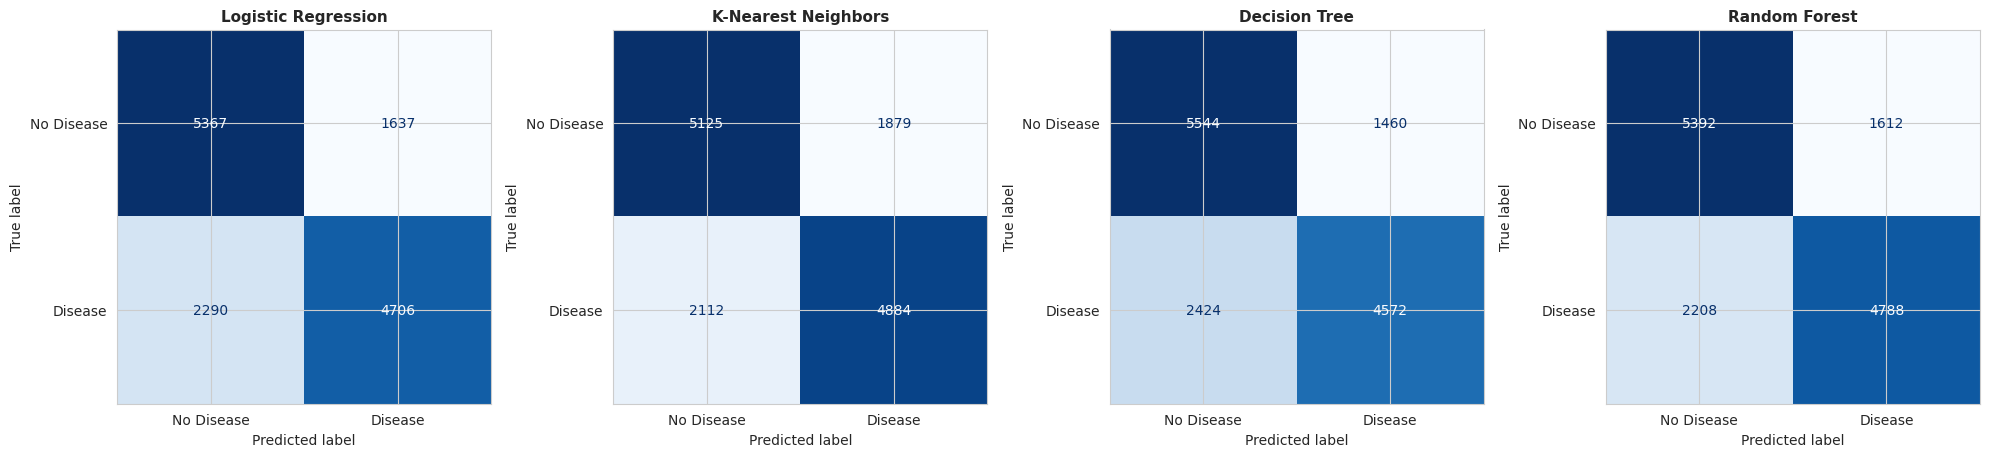

In [ ]:
fig, axes = plt.subplots(1, len(pipelines), figsize=(5 * len(pipelines), 5))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
for name, y_pred in predictions.items():
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    print(f"{name}: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

Logistic Regression: TN=5367, FP=1637, FN=2290, TP=4706
K-Nearest Neighbors: TN=5125, FP=1879, FN=2112, TP=4884
Decision Tree: TN=5544, FP=1460, FN=2424, TP=4572
Random Forest: TN=5392, FP=1612, FN=2208, TP=4788


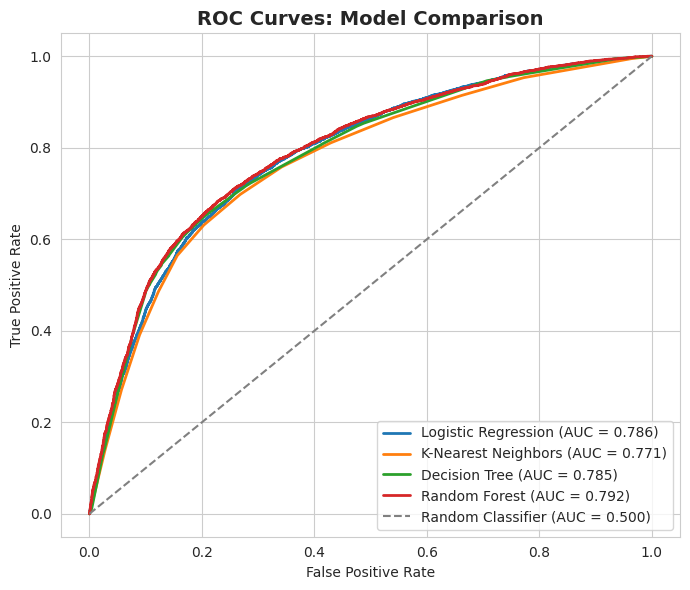

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, y_proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier (AUC = 0.500)')
ax.set_title('ROC Curves: Model Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
best_roc_model = results_df['ROC-AUC'].idxmax()
print(f"Highest ROC-AUC on the test set: {best_roc_model} ({results_df.loc[best_roc_model, 'ROC-AUC']:.4f})")

Highest ROC-AUC on the test set: Random Forest (0.7922)


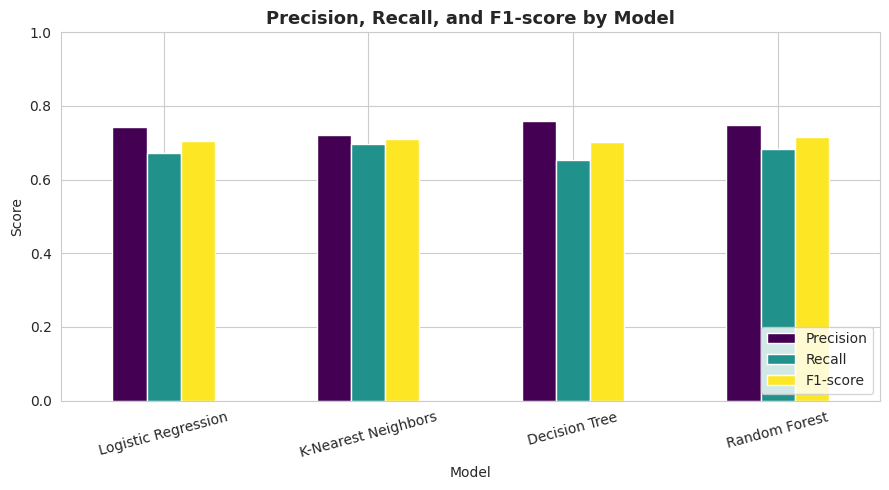

In [ ]:
metrics_to_plot = ['Precision', 'Recall', 'F1-score']
fig, ax = plt.subplots(figsize=(9, 5))
results_df[metrics_to_plot].plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title('Precision, Recall, and F1-score by Model', fontsize=13, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

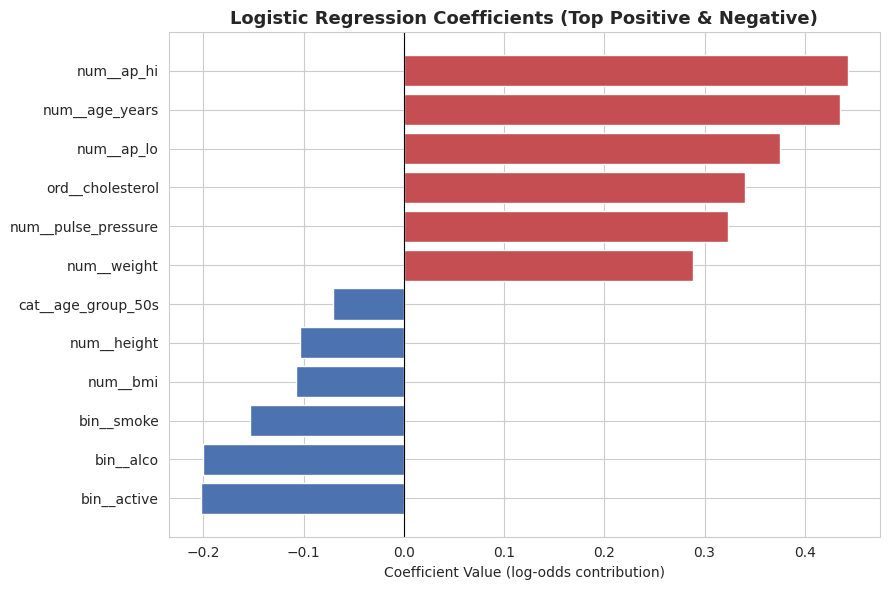

In [ ]:
log_reg_pipe = pipelines['Logistic Regression']
feature_names = log_reg_pipe.named_steps['preprocessor'].get_feature_names_out()
coefs = log_reg_pipe.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs}).sort_values('coefficient')
top_combined = pd.concat([coef_df.head(6), coef_df.tail(6)])

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in top_combined['coefficient']]
ax.barh(top_combined['feature'], top_combined['coefficient'], color=colors)
ax.set_title('Logistic Regression Coefficients (Top Positive & Negative)', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value (log-odds contribution)')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

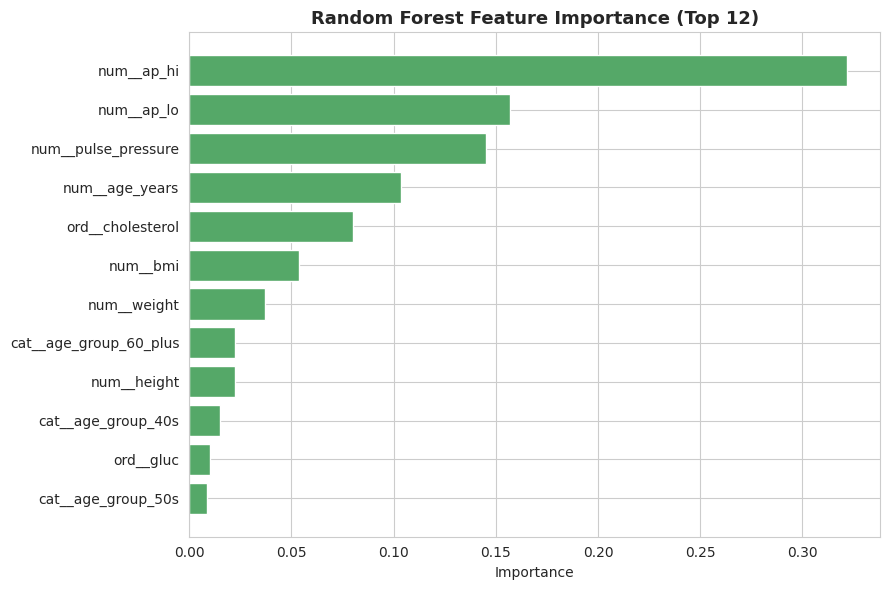

In [ ]:
rf_pipe = pipelines['Random Forest']
rf_feature_names = rf_pipe.named_steps['preprocessor'].get_feature_names_out()
rf_importances = rf_pipe.named_steps['classifier'].feature_importances_

rf_imp_df = pd.DataFrame({'feature': rf_feature_names, 'importance': rf_importances}).sort_values('importance', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(rf_imp_df['feature'][::-1], rf_imp_df['importance'][::-1], color='#55A868')
ax.set_title('Random Forest Feature Importance (Top 12)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
overall = results_df.copy()
overall['CV Accuracy Mean'] = [cv_summary.loc[m, 'CV Accuracy Mean'] for m in overall.index]
overall['CV Accuracy Std'] = [cv_summary.loc[m, 'CV Accuracy Std'] for m in overall.index]
overall['CV ROC-AUC Mean'] = [cv_summary.loc[m, 'CV ROC-AUC Mean'] for m in overall.index]
overall['CV ROC-AUC Std'] = [cv_summary.loc[m, 'CV ROC-AUC Std'] for m in overall.index]
overall.round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC,CV Accuracy Mean,CV Accuracy Std,CV ROC-AUC Mean,CV ROC-AUC Std
Model,,,,,,,,,
Logistic Regression,0.7195,0.7419,0.6727,0.7056,0.7856,0.7252,0.0033,0.7894,0.0027
K-Nearest Neighbors,0.7149,0.7222,0.6981,0.7099,0.7713,0.7138,0.0036,0.7740,0.0035
Decision Tree,0.7226,0.7580,0.6535,0.7019,0.7846,0.7251,0.0036,0.7893,0.0029
Random Forest,0.7271,0.7481,0.6844,0.7148,0.7922,0.7298,0.0026,0.7971,0.0024


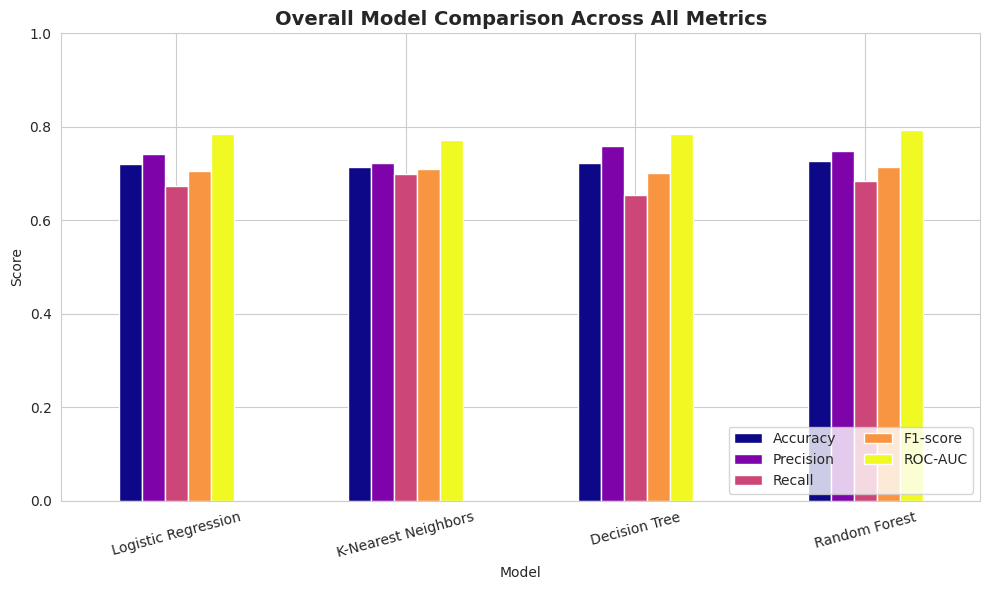

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
overall[metrics_to_plot].plot(kind='bar', ax=ax, colormap='plasma')
ax.set_title('Overall Model Comparison Across All Metrics', fontsize=14, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
plt.xticks(rotation=15)
ax.legend(loc='lower right', ncol=2)
plt.tight_layout()
plt.show()

In [ ]:
best_f1_model = results_df['F1-score'].idxmax()
best_auc_model = results_df['ROC-AUC'].idxmax()
print(f"Best model by F1-score: {best_f1_model} ({results_df.loc[best_f1_model, 'F1-score']:.4f})")
print(f"Best model by ROC-AUC: {best_auc_model} ({results_df.loc[best_auc_model, 'ROC-AUC']:.4f})")

Best model by F1-score: Random Forest (0.7148)
Best model by ROC-AUC: Random Forest (0.7922)


## 17. Key Insights and Conclusion

*(This section summarizes the results actually produced by the cells above — re-run the notebook and the numbers will update automatically.)*

In [ ]:
print(f"Dataset size: {len(df_clean)} patients")
print(f"Class balance: {df_clean['cardio'].mean()*100:.2f}% disease, {(1-df_clean['cardio'].mean())*100:.2f}% no disease")
print()
print("Test-set metrics:")
print(results_df.round(4))
print()
print("Cross-validation metrics (training data only):")
print(cv_summary.round(4))
print()
print(f"Best model by ROC-AUC: {best_auc_model}")
print(f"Best model by F1-score: {best_f1_model}")

Dataset size: 70000 patients
Class balance: 49.97% disease, 50.03% no disease

Test-set metrics:
                     Accuracy  Precision  Recall  F1-score  ROC-AUC
Model                                                              
Logistic Regression    0.7195     0.7419  0.6727    0.7056   0.7856
K-Nearest Neighbors    0.7149     0.7222  0.6981    0.7099   0.7713
Decision Tree          0.7226     0.7580  0.6535    0.7019   0.7846
Random Forest          0.7271     0.7481  0.6844    0.7148   0.7922

Cross-validation metrics (training data only):
                     CV Accuracy Mean  CV Accuracy Std  CV F1 Mean  CV F1 Std  \
Logistic Regression            0.7252           0.0033      0.7103     0.0051   
K-Nearest Neighbors            0.7138           0.0036      0.7076     0.0043   
Decision Tree                  0.7251           0.0036      0.7050     0.0047   
Random Forest                  0.7298           0.0026      0.7167     0.0037   

                     CV ROC-AUC Mean  CV 